In [1]:
import fastf1
import pandas as pd
import os

# 1. The Cache Setup

cache_dir = 'f1_cache'

if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Created cache directory: {cache_dir}")

# Enable cacheing for fastf1, i.e store the downloaded data in this directory
fastf1.Cache.enable_cache(cache_dir)

In [2]:
# Data Ingestion
year = 2025
rounds_to_fetch = [20, 21, 22, 23, 24]

# This list will hold the dataframes for each individual race before we merge them
all_race_results = []

print(f"Fetching data ingestion. Leaving the pit lane...\n")

for current_round in rounds_to_fetch:
    print(f"Fetching data for Year: {year}, Round: {current_round}...")
    
    # R = Race, Q = Qualifying, S = Sprint, FP1 = Free Practice 1, FP2 = Free Practice 2, FP3 = Free Practice 3
    session = fastf1.get_session(year, current_round, 'R')

    session.load(telemetry=False, weather=False, messages=False)

    results = session.results

    results['Race_Name'] = session.event['EventName']
    results['Year'] = year

    all_race_results.append(results)

Fetching data ingestion. Leaving the pit lane...

Fetching data for Year: 2025, Round: 20...


core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '1', '87', '81', '12', '63', '44', '31', '5', '22', '23', '6', '18', '10', '43', '55', '14', '27', '30']
core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Fetching data for Year: 2025, Round: 21...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '1', '63', '81', '87', '30', '6', '27', '10', '23', '31', '55', '14', '43', '18', '22', '44', '16', '5']
core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Fetching data for Year: 2025, Round: 22...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '63'
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '12', '16', '55', '6', '27', '44', '31', '87', '14', '22', '10', '30', '43', '23', '5', '18', '4', '81']
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Fetching data for Year: 2025, Round: 23...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Fetching data for Year: 2025, Round: 24...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


In [3]:
# 3. Data Cleaning and Compilation
master_df = pd.concat(all_race_results, ignore_index=True)

columns_to_keep = [
    'Race_Name',
    'Year',
    'FullName',
    'TeamName',
    'GridPosition',
    'Position',
    'Status'
]

clean_df = master_df[columns_to_keep]

# Position is loaded as float, we need to handle NaNs like DNFs etc... 
clean_df.loc[:, 'Position'] = pd.to_numeric(clean_df['Position'], errors='coerce')
print(f"\n✅ Data ingestion complete! Here is the head of your new dataset:")
print("-"*60)
print(clean_df.head(10))


✅ Data ingestion complete! Here is the head of your new dataset:
------------------------------------------------------------
                Race_Name  Year  ... Position    Status
0  Mexico City Grand Prix  2025  ...      1.0  Finished
1  Mexico City Grand Prix  2025  ...      2.0  Finished
2  Mexico City Grand Prix  2025  ...      3.0  Finished
3  Mexico City Grand Prix  2025  ...      4.0  Finished
4  Mexico City Grand Prix  2025  ...      5.0  Finished
5  Mexico City Grand Prix  2025  ...      6.0  Finished
6  Mexico City Grand Prix  2025  ...      7.0  Finished
7  Mexico City Grand Prix  2025  ...      8.0  Finished
8  Mexico City Grand Prix  2025  ...      9.0  Finished
9  Mexico City Grand Prix  2025  ...     10.0  Finished

[10 rows x 7 columns]


In [4]:
# Phase 2: Exploratory Data Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting Exploratory Data Analysis...\n")

# 2.1 Create the target variable

clean_df['Position'] = clean_df['Position'].fillna(20)

clean_df['is_points_finish'] = (clean_df['Position'] <= 10).astype(int)

print("✅ Target variable 'is_points_finish' created successfully! Here is the distribution:")
print(f"Total Points Finishes in dataset: {clean_df['is_points_finish'].sum()}")
print(f"total Non-Points Finishes: {len(clean_df) - clean_df['is_points_finish'].sum()}\n")



Starting Exploratory Data Analysis...

✅ Target variable 'is_points_finish' created successfully! Here is the distribution:
Total Points Finishes in dataset: 50
total Non-Points Finishes: 50



C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\765126564.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Position'] = clean_df['Position'].fillna(20)
C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\765126564.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['is_points_finish'] = (clean_df['Position'] <= 10).astype(int)


In [5]:
#2.2 Analyze Grid Position vs Points

grid_stats = clean_df.groupby('GridPosition')['is_points_finish'].mean().reset_index()
grid_stats.rename(columns={'is_points_finish': 'Points_Probability'}, inplace=True)

grid_stats = grid_stats[(grid_stats['GridPosition'] > 0) & (grid_stats['GridPosition'] <= 20)]

print("Probability of scoring points by Grid Position:")
print(grid_stats.head(10))

Probability of scoring points by Grid Position:
   GridPosition  Points_Probability
0           1.0                 0.8
1           2.0                 1.0
2           3.0                 0.8
3           4.0                 1.0
4           5.0                 0.8
5           6.0                 0.6
6           7.0                 0.6
7           8.0                 0.8
8           9.0                 0.6
9          10.0                 0.4


C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\1997255305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="GridPosition", y="Points_Probability", data=grid_stats, palette="viridis")


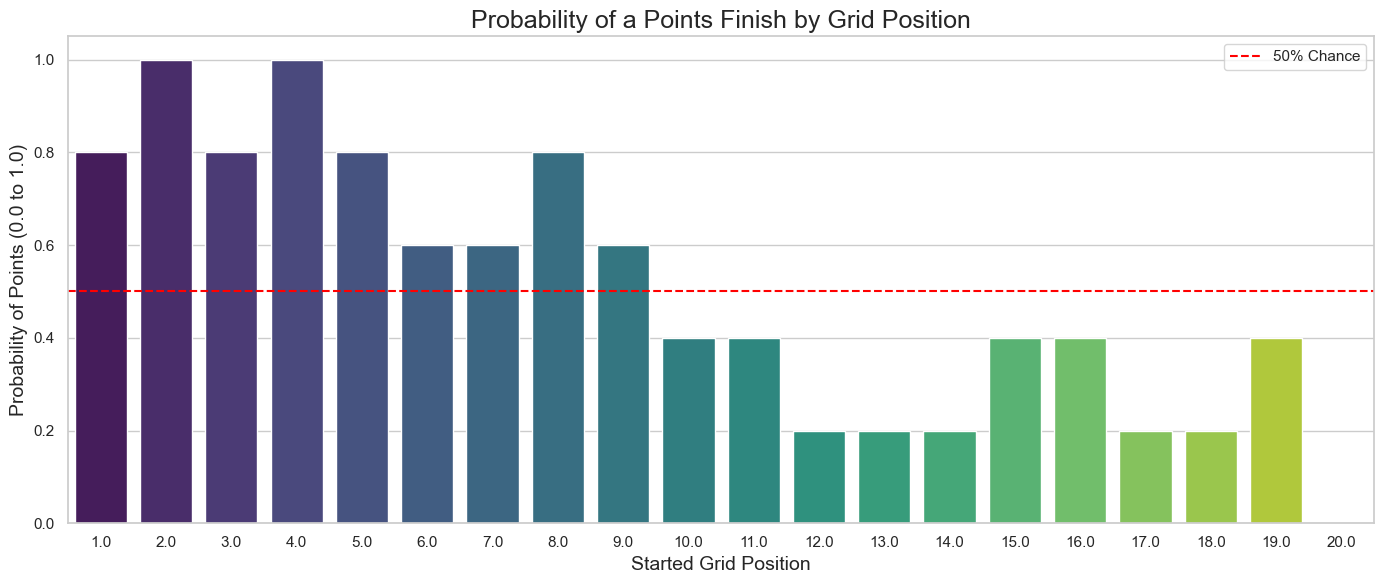

C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\1997255305.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TeamName', y='Position', data=clean_df, palette="Set2")


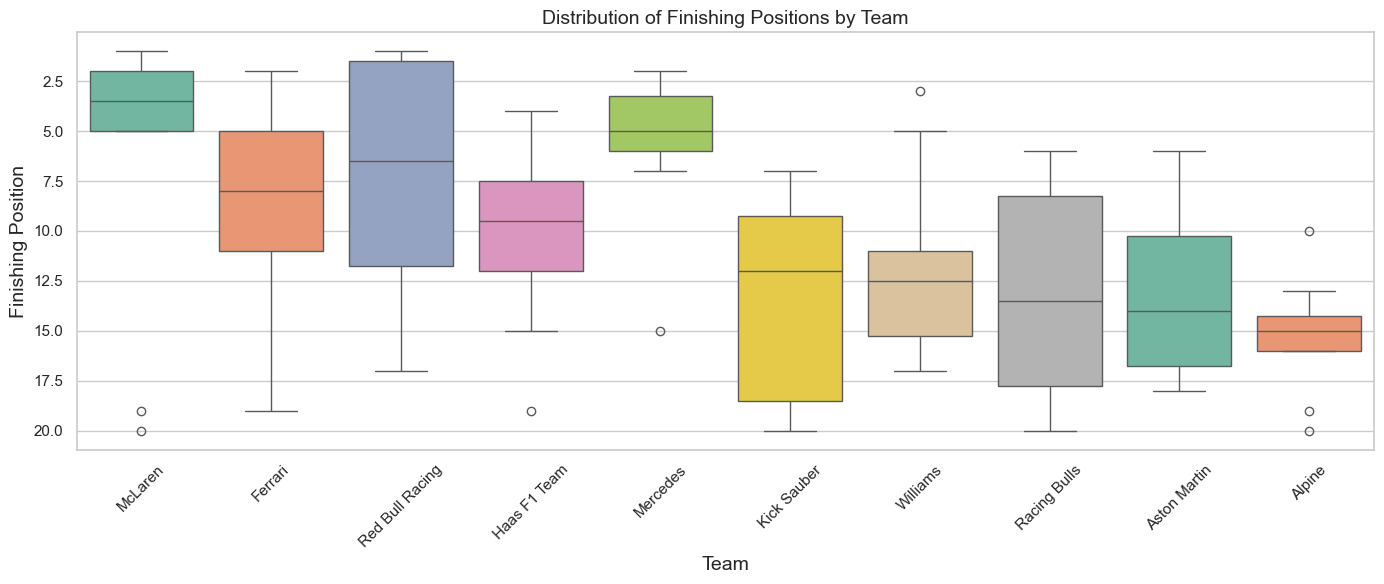

In [6]:
# 2.3 Visualization

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))
sns.barplot(x="GridPosition", y="Points_Probability", data=grid_stats, palette="viridis")
plt.title("Probability of a Points Finish by Grid Position", fontsize=18)
plt.xlabel("Started Grid Position", fontsize=14)
plt.ylabel("Probability of Points (0.0 to 1.0)", fontsize=14)
plt.axhline(y=0.5, color='red', linestyle='--', label='50% Chance')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(x='TeamName', y='Position', data=clean_df, palette="Set2")
plt.title("Distribution of Finishing Positions by Team", fontsize=14)
plt.xlabel("Team", fontsize=14)
plt.ylabel("Finishing Position", fontsize=14)
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The Bar Chart: You should see a clear downward "staircase." Drivers starting P1-P5 have a massive probability of finishing in the points. Drivers starting P16-P20 have very little chance. This confirms that GridPosition is a highly predictive feature for our model.

The Box Plot: You will notice that top teams (like Red Bull, McLaren, or Ferrari) have tightly clustered finishing positions near the top (1-5), while backmarkers have wider spreads lower down the order.

In [7]:
# Phase 3: Feature Engineering
import pandas as pd
print("Starting Feature Engineering...\n")

# 3.1 Re-Apply the target values
clean_df['Position'] = pd.to_numeric(clean_df['Position'], errors='coerce').fillna(20)
clean_df['is_points_finish'] = (clean_df['Position'] <= 10).astype(int)

# 3.2 Top team indicators.
''' In F1, car is as important as the driver, creating binary features highlighting the traditional top 4 teams
note that these teams may change as per the year choosen'''

top_teams = ['Red Bull Racing', 'Ferrari', 'McLaren', 'Mercedes']
clean_df['is_top_team'] = clean_df['TeamName'].apply(lambda x: 1 if x in top_teams else 0)

# 3.3 Categorical encoding - One-hot encoding
ml_df = pd.get_dummies(clean_df, columns=['TeamName'], drop_first=True)

# 3.4 Preventing Target Leakage
features_to_drop = ['FullName', 'Race_Name', 'Year', 'Position', 'Status']
ml_df = ml_df.drop(columns=features_to_drop)

print("✅ Feature engineering complete! The dataset is ready for the model...")
print("-" * 60)
print(ml_df.info())
print("\nFirst 5 rows of our ML-ready data:")
print(ml_df.head())




Starting Feature Engineering...

✅ Feature engineering complete! The dataset is ready for the model...
------------------------------------------------------------
<class 'fastf1.core.SessionResults'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   GridPosition              100 non-null    float64
 1   is_points_finish          100 non-null    int64  
 2   is_top_team               100 non-null    int64  
 3   TeamName_Aston Martin     100 non-null    bool   
 4   TeamName_Ferrari          100 non-null    bool   
 5   TeamName_Haas F1 Team     100 non-null    bool   
 6   TeamName_Kick Sauber      100 non-null    bool   
 7   TeamName_McLaren          100 non-null    bool   
 8   TeamName_Mercedes         100 non-null    bool   
 9   TeamName_Racing Bulls     100 non-null    bool   
 10  TeamName_Red Bull Racing  100 non-null    bool   
 11  TeamName_Will

C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\267803442.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Position'] = pd.to_numeric(clean_df['Position'], errors='coerce').fillna(20)
C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\267803442.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['is_points_finish'] = (clean_df['Position'] <= 10).astype(int)
C:\Users\Pratham R Gowda\AppData\Local\Temp\ipykernel_9796\267803442.py:14: SettingWithCopyWarning: 
A value is

In [8]:
# Phase 4: Model Training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Starting Model Training...\n")

X = ml_df.drop(columns=['is_points_finish'])
y = ml_df['is_points_finish']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

print("Starting the engine... Training the model...")
rf_model.fit(X_train, y_train)
print("Model Training Complete!\n")

sample_prediction = rf_model.predict(X_test)
print("Sample Predictions on Test Set (1 = Points finish, 0 = Non points finish): ")
print(sample_prediction[:10])

Starting Model Training...

Starting the engine... Training the model...
Model Training Complete!

Sample Predictions on Test Set (1 = Points finish, 0 = Non points finish): 
[1 1 1 1 1 0 1 0 0 0]


Using a random split (shuffle=True).
 If you shuffle sports data, you might train the model on Race 5 to predict Race 2. 
 That's time-traveling (Target Leakage). 
 By setting shuffle=False, we train on the first 80% of races (chronologically) 
 and test on the final 20% (the last race in our dataset).